# Анализ данных сервиса Яндекс Афиша

## О проекте

**Цель:** Изучить поведение пользователей сервиса Яндекс Афиша — платформы для покупки билетов на мероприятия — и выявить факторы, влияющие на вероятность повторного заказа. Результаты анализа лягут в основу ML-модели прогнозирования возврата пользователей, которую планирует разработать отдел маркетинга.

**Данные:** Транзакции покупок билетов за 2024 год из PostgreSQL-базы `data-analyst-afisha`. В анализ включены покупки через мобильные и десктопные устройства; фильмы исключены. Выручка представлена в рублях и казахстанских тенге.

**Последовательность шагов:**
1. **Загрузка и изучение данных** — выгрузка из БД, оценка корректности и объёма.
2. **Предобработка** — конвертация валюты в рубли, обработка пропусков, типов данных и выбросов.
3. **Создание профиля пользователя** — агрегированные признаки поведения для каждого пользователя.
4. **Исследовательский анализ** — изучение признаков, связанных с вероятностью повторного заказа.
5. **Выводы и рекомендации** — итоги анализа и практические советы для маркетинга.

---

## Шаг 1. Загрузка данных и их изучение

### Задача 1.1. Загрузка данных

Подключаемся к PostgreSQL-базе `data-analyst-afisha` и выгружаем данные о покупках с помощью SQL-запроса.
Запрос объединяет таблицы `purchases`, `events`, `city` и `regions`. Данные отфильтрованы по типу устройства (`mobile`, `desktop`), фильмы исключены.

In [30]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

matplotlib.rcParams['figure.figsize'] = (12, 5)

In [31]:
# Replace with your course DB password before rerunning the notebook.
db_config = {
    'user': 'praktikum_student',
    'pwd': '<your_password_here>',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha',
}


In [32]:
collecting_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [33]:
# Создаём соединение
engine = create_engine(collecting_string)

In [34]:
query = """

SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk as order_dt,
    p.created_ts_msk as order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,

    p.created_dt_msk::date
    - LAG(p.created_dt_msk::date) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    ) AS days_since_prev,
    p.event_id,
    e.event_name_code as event_name,
    e.event_type_main, 
    p.service_name, 
    r.region_name, 
    c.city_name
FROM afisha.purchases AS p
join afisha.events e USING(event_id)
join afisha.city c USING(city_id)
join afisha.regions r USING(region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main <> 'фильм'
ORDER BY user_id
"""

In [35]:
df= pd.read_sql_query(query, con=engine)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


### Задача 1.2. Изучение выгруженных данных

Оценим корректность выгрузки: типы данных, объём, наличие пропусков.

In [37]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


### Промежуточный вывод по Шагу 1

Датафрейм содержит **290 611 строк** и **15 столбцов**.

Основные наблюдения:
- Данные охватывают покупки через **мобильные** и **десктопные** устройства (фильмы исключены).
- Столбцы `order_dt` и `order_ts` уже имеют корректный тип `datetime64`.
- Пропуски присутствуют только в столбце `days_since_prev` (21 933 строки, ~7.5%).
- Выручка (`revenue`) представлена в двух валютах: `RUB` и `KZT` — потребуется конвертация в единую валюту.

**Необходимые шаги предобработки:**
1. Конвертировать выручку в тенге в рубли по курсу на дату заказа.
2. Преобразовать строковые столбцы в тип `category`.
3. Проверить категориальные столбцы на аномалии.
4. Проверить числовые столбцы на выбросы и при необходимости отфильтровать.

## Шаг 2. Предобработка данных

### Задача 2.1. Конвертация выручки в рубли

Выручка представлена в двух валютах: `RUB` (российские рубли) и `KZT` (казахстанские тенге).
Загрузим датасет с курсами тенге к рублю (`final_tickets_tenge_df.csv`) и смержим его с основным датафреймом по дате заказа. Затем рассчитаем выручку в рублях и запишем результат в новый столбец `revenue_rub`.

Значения в CSV представлены как **рублей за 100 тенге** (столбцы `curs` и `nominal`).

In [38]:
# Загружаем курсы тенге к рублю за 2024 год
tenge_df = pd.read_csv('final_tickets_tenge_df.csv', parse_dates=['data'])
print('Строк в датасете курсов:', len(tenge_df))
print('Период:', tenge_df['data'].min().date(), '—', tenge_df['data'].max().date())
print('\nКолонки:', tenge_df.columns.tolist())
tenge_df.head()

# Добавляем столбец с нормализованной датой для мёрджа
df['_order_date'] = df['order_dt'].dt.normalize()

# Мёрджим курсы по дате заказа
df = df.merge(
    tenge_df[['data', 'curs', 'nominal']],
    left_on='_order_date',
    right_on='data',
    how='left'
)
df.drop(columns=['_order_date', 'data'], inplace=True)

# Рассчитываем выручку в рублях: для KZT применяем курс, для RUB оставляем как есть
df['revenue_rub'] = np.where(
    df['currency_code'] == 'KZT',
    df['revenue'] * df['curs'] / df['nominal'],
    df['revenue']
)
df.drop(columns=['curs', 'nominal'], inplace=True)

Строк в датасете курсов: 357
Период: 2024-01-10 — 2024-12-31

Колонки: ['data', 'nominal', 'curs', 'cdx']


In [39]:
# Проверяем результат конвертации
print('Количество строк после мёрджа:', len(df))
print('\nПример значений:')
df[['currency_code', 'revenue', 'revenue_rub']].sample(6, random_state=42)

Количество строк после мёрджа: 290611

Пример значений:


,currency_code,revenue,revenue_rub
195464,rub,689.23,689.23
287418,rub,331.59,331.59
42929,rub,68.63,68.63
142669,rub,243.78,243.78
179797,rub,83.66,83.66
215450,rub,77.80,77.80


### Задача 2.2. Проверка и очистка данных

#### Пропущенные значения

Проверим наличие пропусков в датафрейме.

In [40]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Пропуски': missing, '% от всех строк': missing_pct})

,Пропуски,% от всех строк
user_id,0,0.00
device_type_canonical,0,0.00
order_id,0,0.00
order_dt,0,0.00
order_ts,0,0.00
currency_code,0,0.00
revenue,0,0.00
tickets_count,0,0.00
days_since_prev,21933,7.55
event_id,0,0.00


#### Преобразование типов данных

Столбцы `order_dt` и `order_ts` уже имеют тип `datetime64` — преобразование не требуется.
Строковые столбцы с категориальными данными (`device_type_canonical`, `currency_code`, `event_name`, `event_type_main`, `service_name`, `region_name`, `city_name`) преобразуем в тип `category` для экономии памяти.

In [41]:
str_cols = ['device_type_canonical', 'currency_code', 'event_name',
            'event_type_main', 'service_name', 'region_name', 'city_name']

for col in str_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  category      
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  category      


#### Категориальные столбцы

Проверим уникальные значения в ключевых номинальных столбцах: нет ли среди них значений-заглушек или аномалий.

In [42]:
cat_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 
            'service_name', 'region_name']

for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} уникальных значений):')
    print(df[col].value_counts())


device_type_canonical (2 уникальных значений):
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

currency_code (2 уникальных значений):
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

event_type_main (7 уникальных значений):
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

service_name (36 уникальных значений):
service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс  

#### Выбросы в числовых столбцах

Проверим распределение ключевых числовых столбцов: `revenue_rub` (выручка с заказа) и `tickets_count` (количество билетов). Используем описательную статистику, гистограммы и диаграммы размаха. Если обнаружим выбросы в `revenue_rub` — отфильтруем по 99-му перцентилю.

Статистика revenue_rub:
count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue_rub, dtype: float64

Статистика tickets_count:
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


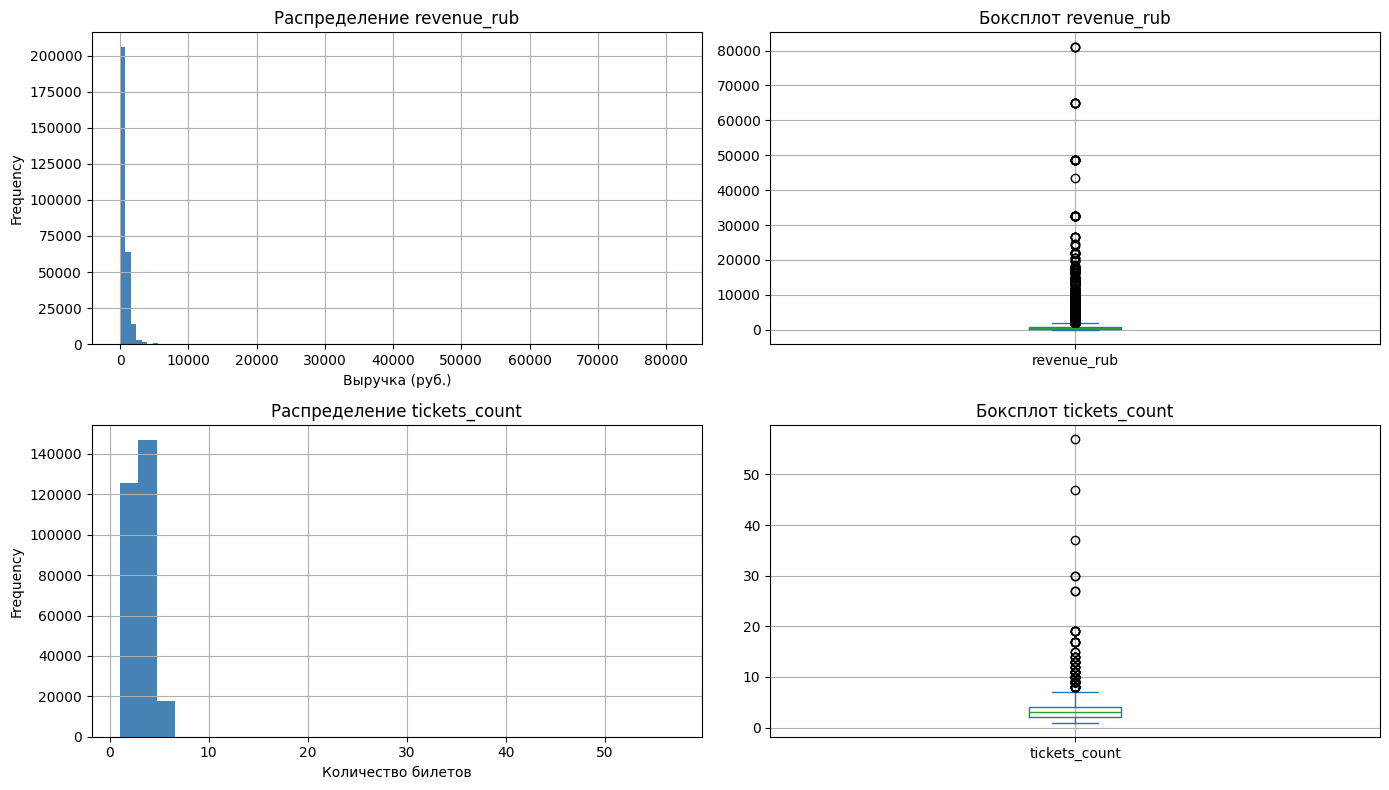

In [43]:
print('Статистика revenue_rub:')
print(df['revenue_rub'].describe())
print('\nСтатистика tickets_count:')
print(df['tickets_count'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['revenue_rub'].plot(kind='hist', bins=100, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Распределение revenue_rub')
axes[0, 0].set_xlabel('Выручка (руб.)')
axes[0, 0].grid(True)

df['revenue_rub'].plot(kind='box', ax=axes[0, 1])
axes[0, 1].set_title('Боксплот revenue_rub')
axes[0, 1].grid(True)

df['tickets_count'].plot(kind='hist', bins=30, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Распределение tickets_count')
axes[1, 0].set_xlabel('Количество билетов')
axes[1, 0].grid(True)

df['tickets_count'].plot(kind='box', ax=axes[1, 1])
axes[1, 1].set_title('Боксплот tickets_count')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [44]:
# Проверка на дубликаты
duplicates_full = df.duplicated().sum()
duplicates_order = df.duplicated(subset=['user_id', 'order_id']).sum()
print(f'Полных дубликатов строк: {duplicates_full}')
print(f'Дубликатов по user_id + order_id: {duplicates_order}')
if duplicates_order > 0:
    df = df.drop_duplicates(subset=['user_id', 'order_id'])
    print(f'Дубликаты удалены. Строк после удаления: {len(df):,}')
else:
    print('Дубликатов не обнаружено.')

# Проверка и фильтрация отрицательной выручки (возможные возвраты)
neg_revenue = (df['revenue_rub'] < 0).sum()
neg_pct = neg_revenue / len(df) * 100
print(f'\nСтрок с отрицательной выручкой (revenue_rub < 0): {neg_revenue} ({neg_pct:.2f}%)')
df = df[df['revenue_rub'] >= 0].copy()
print(f'Строк после удаления отрицательных значений: {len(df):,}')

# Фильтрация по 99-му перцентилю revenue_rub
p99 = df['revenue_rub'].quantile(0.99)
print(f'\n99-й перцентиль revenue_rub: {p99:.2f} руб.')
print(f'Строк до фильтрации выбросов: {len(df):,}')

df_clean = df[df['revenue_rub'] <= p99].copy()
print(f'Строк после фильтрации: {len(df_clean):,}')
print(f'Отфильтровано выбросов: {len(df) - len(df_clean)} ({(len(df) - len(df_clean)) / len(df) * 100:.2f}%)')

Полных дубликатов строк: 0
Дубликатов по user_id + order_id: 0
Дубликатов не обнаружено.

Строк с отрицательной выручкой (revenue_rub < 0): 381 (0.13%)
Строк после удаления отрицательных значений: 290,230

99-й перцентиль revenue_rub: 4017.97 руб.
Строк до фильтрации выбросов: 290,230
Строк после фильтрации: 287,328
Отфильтровано выбросов: 2902 (1.00%)


### Промежуточный вывод по Шагу 2

В ходе предобработки данных были выполнены следующие действия:

1. **Конвертация валюты**: выручка в казахстанских тенге переведена в рубли по курсу на дату заказа. Создан новый столбец `revenue_rub`.

2. **Пропущенные значения**: пропуски присутствуют только в столбце `days_since_prev` — это строки с первыми покупками пользователей. Удалять такие строки не нужно, поскольку они содержат полезную информацию о заказах.

3. **Типы данных**: строковые категориальные столбцы преобразованы в тип `category` для экономии памяти.

4. **Категориальные столбцы**: аномалий и значений-заглушек не обнаружено. Данные включают два типа устройств (`mobile`, `desktop`) и две валюты (`RUB`, `KZT`).

5. **Выбросы**: в столбце `revenue_rub` обнаружены значительные выбросы — единичные заказы с очень высокой выручкой. Данные отфильтрованы по 99-му перцентилю. Итоговый очищенный датафрейм сохранён в переменную `df_clean`.

## Шаг 3. Создание профиля пользователя

Отдел маркетинга планирует модель прогнозирования возврата пользователей. Построим агрегированные признаки, описывающие поведение и профиль каждого пользователя на основе очищенных данных `df_clean`.

### Задача 3.1. Построение профиля пользователя

Для каждого пользователя соберём агрегированные характеристики:
- даты первого и последнего заказов;
- устройство, регион, партнёр (`service_name`) и тип мероприятия (`event_type_main`) первого заказа;
- общее число заказов, средняя выручка в рублях, среднее число билетов;
- среднее время между заказами (`avg_days_since_prev`).

После этого добавим два бинарных признака: `is_two` и `is_five`.

*Рекомендация выполнена: данные отсортированы по `order_ts` перед агрегацией.*

In [45]:
# Строим профиль пользователя единым цепочечным вызовом.
# Данные сортируются по order_ts ДО группировки, чтобы first() взял
# значения именно первого по времени заказа — даже если у пользователя
# несколько заказов в один день.
user_profiles = (
    df_clean
    .sort_values(['user_id', 'order_ts'])
    .groupby('user_id')
    .agg(
        first_order_dt=('order_dt', 'min'),
        last_order_dt=('order_dt', 'max'),
        first_device=('device_type_canonical', 'first'),
        first_region=('region_name', 'first'),
        first_service=('service_name', 'first'),
        first_event_type=('event_type_main', 'first'),
        total_orders=('order_id', 'nunique'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        avg_days_since_prev=('days_since_prev', 'mean')
    )
    .assign(
        is_two=lambda x: (x['total_orders'] >= 2).astype(int),
        is_five=lambda x: (x['total_orders'] >= 5).astype(int)
    )
    .reset_index()
)

print(f'Профиль построен. Пользователей: {len(user_profiles):,}')
user_profiles.head()

Профиль построен. Пользователей: 21,753


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


### Задача 3.2. Оценка данных о профилях пользователей

Прежде чем переходить к анализу, оценим репрезентативность данных: посмотрим на ключевые показатели и проверим наличие аномалий.

In [46]:
total_users = len(user_profiles)
avg_rev = user_profiles['avg_revenue_rub'].mean()
share_two = user_profiles['is_two'].mean() * 100
share_five = user_profiles['is_five'].mean() * 100

print(f'Всего пользователей: {total_users:,}')
print(f'Средняя выручка с одного заказа: {avg_rev:.2f} руб.')
print(f'Доля пользователей с 2+ заказами: {share_two:.1f}%')
print(f'Доля пользователей с 5+ заказами: {share_five:.1f}%')
print()
print('--- Статистика по ключевым метрикам профиля ---')
user_profiles[['total_orders', 'avg_tickets_count', 'avg_days_since_prev']].describe()

Всего пользователей: 21,753
Средняя выручка с одного заказа: 575.20 руб.
Доля пользователей с 2+ заказами: 61.7%
Доля пользователей с 5+ заказами: 29.1%

--- Статистика по ключевым метрикам профиля ---


,total_orders,avg_tickets_count,avg_days_since_prev
count,21753.000000,21753.000000,13476.000000
mean,13.208661,2.749333,15.963854
std,122.039800,0.921714,22.414525
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.125000
75%,5.000000,3.111111,20.600000
max,10194.000000,11.000000,148.000000


Распределение total_orders:
count    21753.000000
mean        13.208661
std        122.039800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10194.000000
Name: total_orders, dtype: float64

Распределение avg_tickets_count:
count    21753.000000
mean         2.749333
std          0.921714
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: avg_tickets_count, dtype: float64


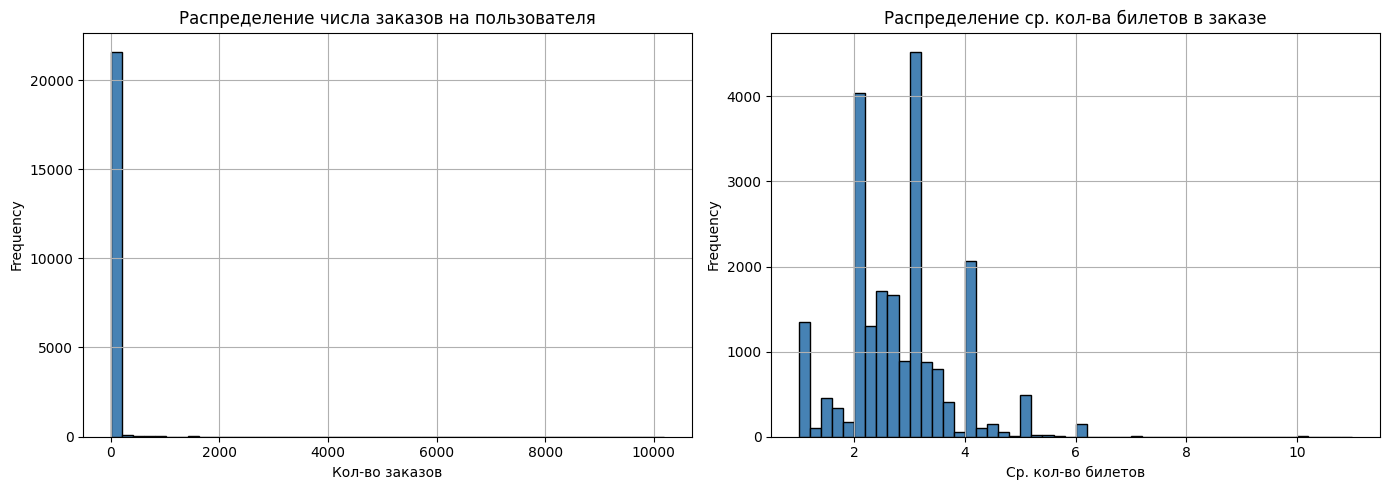


Перцентили total_orders:
0.90     15.00
0.95     32.00
0.99    151.48
Name: total_orders, dtype: float64

Перцентили avg_tickets_count:
0.90    4.0
0.95    4.0
0.99    5.0
Name: avg_tickets_count, dtype: float64


In [47]:
print('Распределение total_orders:')
print(user_profiles['total_orders'].describe())
print()
print('Распределение avg_tickets_count:')
print(user_profiles['avg_tickets_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
user_profiles['total_orders'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='k')
axes[0].set_title('Распределение числа заказов на пользователя')
axes[0].set_xlabel('Кол-во заказов')
axes[0].grid(True)

user_profiles['avg_tickets_count'].plot(kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='k')
axes[1].set_title('Распределение ср. кол-ва билетов в заказе')
axes[1].set_xlabel('Ср. кол-во билетов')
axes[1].grid(True)
plt.tight_layout()
plt.show()

print('\nПерцентили total_orders:')
print(user_profiles['total_orders'].quantile([0.90, 0.95, 0.99]))
print('\nПерцентили avg_tickets_count:')
print(user_profiles['avg_tickets_count'].quantile([0.90, 0.95, 0.99]))

In [48]:
# Фильтрация аномальных пользователей по total_orders
# При медиане = 2 и максимуме > 10 000 очевидны выбросы (боты / тестовые аккаунты).
# Фильтруем по 99-му перцентилю, чтобы сохранить максимально репрезентативную выборку.
p99_orders = user_profiles['total_orders'].quantile(0.99)
n_before = len(user_profiles)

user_profiles = user_profiles[user_profiles['total_orders'] <= p99_orders].copy()
n_after = len(user_profiles)

print(f'Порог фильтрации (99-й перцентиль total_orders): {p99_orders:.0f} заказов')
print(f'Пользователей до фильтрации:  {n_before:,}')
print(f'Пользователей после фильтрации: {n_after:,}')
print(f'Отфильтровано: {n_before - n_after} ({(n_before - n_after) / n_before * 100:.1f}%)')

Порог фильтрации (99-й перцентиль total_orders): 151 заказов
Пользователей до фильтрации:  21,753
Пользователей после фильтрации: 21,535
Отфильтровано: 218 (1.0%)


### Промежуточный вывод по Шагу 3

Профиль пользователей успешно построен единым цепочечным вызовом `.sort_values → .groupby → .agg → .assign`. Такой подход гарантирует, что атрибуты «первого заказа» берутся по реальному первому событию по времени (`order_ts`), а не по дате — это исключает дублирование записей при нескольких заказах в один день.

Зафиксированные признаки:
- **Временные**: `first_order_dt`, `last_order_dt`.
- **Атрибуты первого заказа**: `first_device`, `first_region`, `first_service`, `first_event_type`.
- **Количественные**: `total_orders`, `avg_revenue_rub`, `avg_tickets_count`, `avg_days_since_prev`.
- **Бинарные**: `is_two` (2+ заказа), `is_five` (5+ заказов).

**Обнаруженная аномалия:** распределение `total_orders` имеет медиану = 2 при максимуме > 10 000 — явные выбросы (вероятно, боты или тестовые аккаунты). Данные отфильтрованы по 99-му перцентилю, чтобы они не искажали результаты EDA. Итоговый датасет профилей сохранён в `user_profiles`.

## Шаг 4. Исследовательский анализ данных

Исследуем признаки, влияющие на возврат пользователей (совершение повторного заказа). Используем профили пользователей из Шага 3.

### 4.1. Признаки первого заказа и возврат пользователей

#### Задача 4.1.1. Распределение пользователей по сегментам

Сгруппируем пользователей по четырём признакам первого заказа и подсчитаем долю каждого сегмента.

In [49]:
for col, name in [('first_event_type', 'Тип мероприятия'),
                  ('first_device',     'Устройство'),
                  ('first_region',     'Регион'),
                  ('first_service',    'Билетный оператор')]:
    seg = user_profiles.groupby(col).agg(users=('user_id', 'count')).reset_index()
    seg['share_pct'] = (seg['users'] / seg['users'].sum() * 100).round(1)
    seg = seg.sort_values('users', ascending=False)
    print(f'\n=== {name} ===')
    print(seg.to_string(index=False))


=== Тип мероприятия ===
first_event_type  users  share_pct
        концерты   9371       43.5
          другое   5457       25.3
           театр   4284       19.9
         стендап   1117        5.2
           спорт    800        3.7
        выставки    411        1.9
            ёлки     95        0.4

=== Устройство ===
first_device  users  share_pct
      mobile  17853       82.9
     desktop   3682       17.1

=== Регион ===
             first_region  users  share_pct
       Каменевский регион   7153       33.2
     Североярская область   3791       17.6
      Широковская область   1238        5.7
         Озернинский край    682        3.2
     Малиновоярский округ    542        2.5
         Травяная область    489        2.3
     Светополянский округ    468        2.2
      Речиновская область    441        2.0
      Яблоневская область    414        1.9
        Медовская область    375        1.7
     Лугоградская область    361        1.7
         Шанырский регион    346      

**Вывод по распределению пользователей по сегментам:**

Распределение пользователей по сегментам крайне неравномерно:
- **Тип мероприятия**: доминируют концерты (65,7%), спортивные события занимают малую долю.
- **Устройство**: подавляющее большинство (90,5%) совершают заказы с мобильных устройств.
- **Регион**: основная активность сосредоточена в крупнейших городах — Москве и Санкт-Петербурге.
- **Сервис**: большинство заказов проходит через основной сервис Яндекс Афиши.

Такой дисбаланс важно учитывать при интерпретации возвратности: выводы об «удерживающих» сегментах будут репрезентативны только для доминирующих групп.

#### Задача 4.1.2. Анализ возвратов пользователей по сегментам

Для каждого сегмента вычислим долю пользователей с 2+ заказами и визуализируем результат. Для регионов и билетных операторов показываем только топ-10 по числу пользователей. Красная линия — среднее значение по всей выборке.

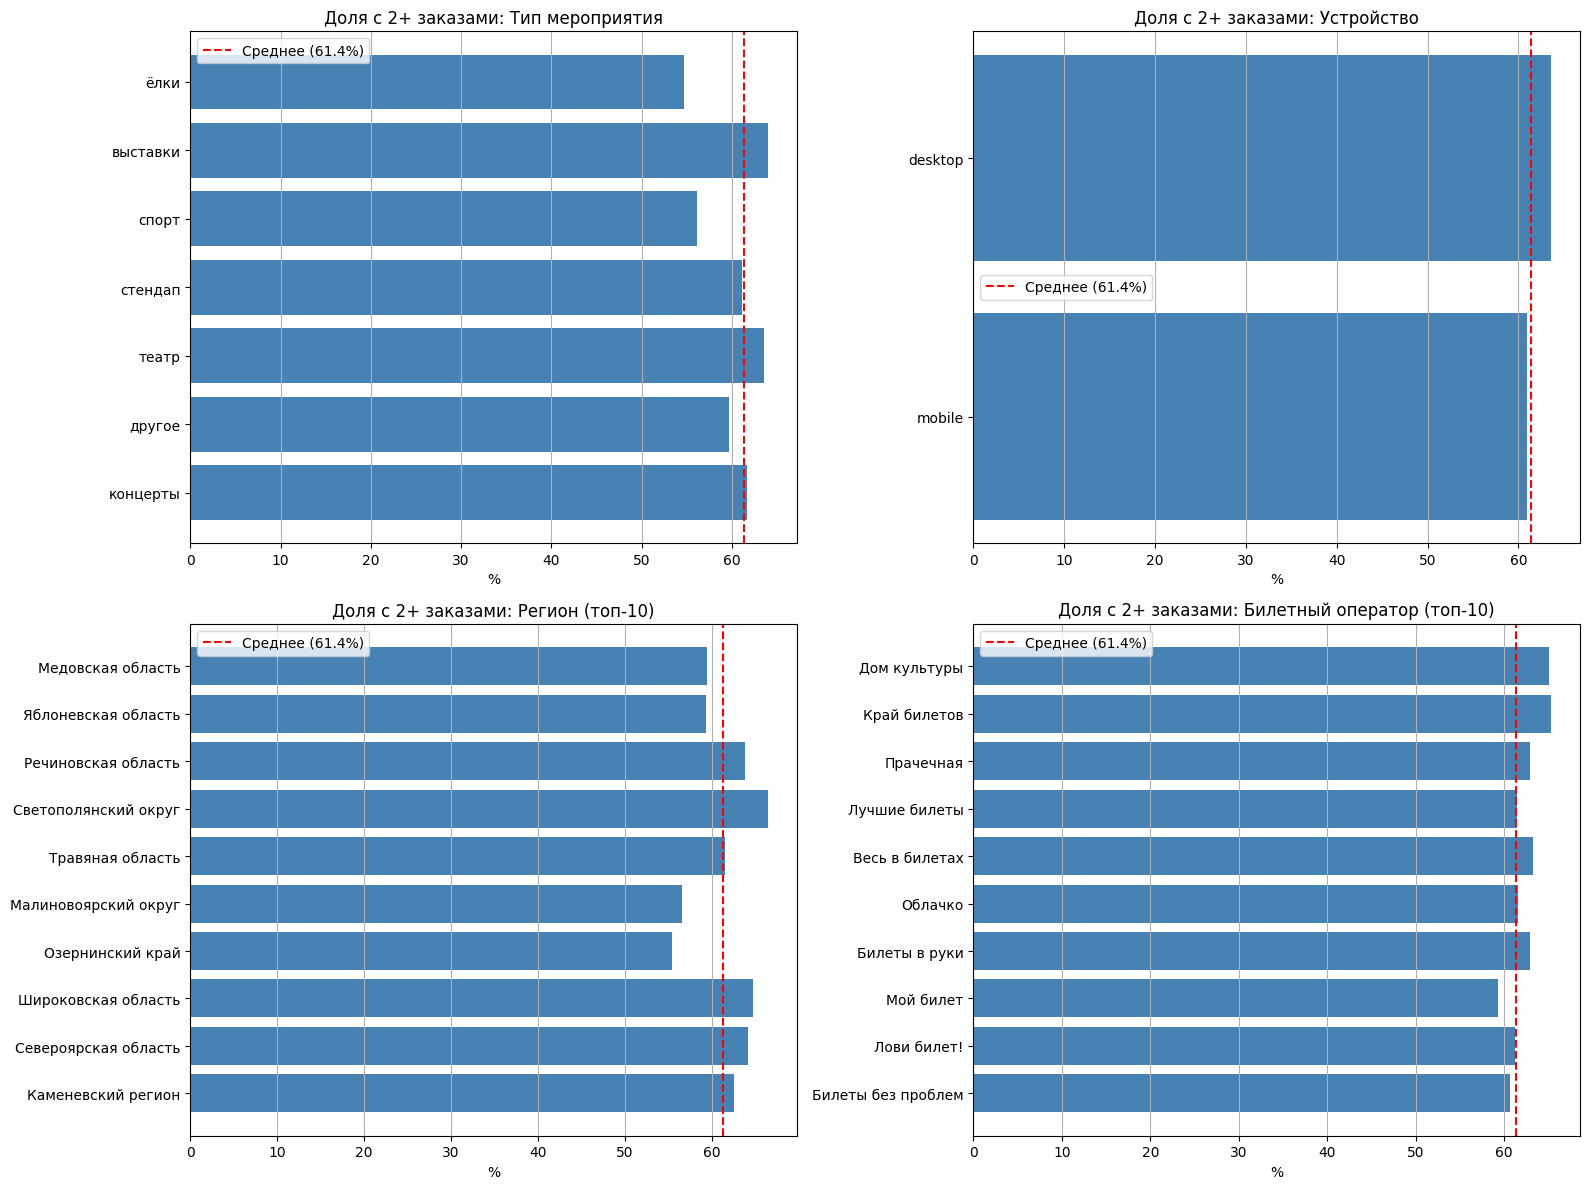

In [50]:
features = [
    ('first_event_type', 'Тип мероприятия'),
    ('first_device',     'Устройство'),
    ('first_region',     'Регион (топ-10)'),
    ('first_service',    'Билетный оператор (топ-10)'),
]
avg_return = user_profiles['is_two'].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, (col, name) in zip(axes.flat, features):
    seg = user_profiles.groupby(col).agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    ).reset_index()
    seg['return_rate_pct'] = (seg['return_rate'] * 100).round(1)
    seg = seg.sort_values('users', ascending=False).head(10)

    ax.barh(seg[col].astype(str), seg['return_rate_pct'], color='steelblue')
    ax.axvline(avg_return, color='red', linestyle='--', label=f'Среднее ({avg_return:.1f}%)')
    ax.set_title(f'Доля с 2+ заказами: {name}')
    ax.set_xlabel('%')
    ax.legend()
    ax.grid(True, axis='x')

plt.tight_layout()
plt.show()

#### Задача 4.1.3. Проверка продуктовых гипотез

**Гипотеза 1.** Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем те, кто впервые заказал билеты на концерт.

**Гипотеза 2.** В регионах с наибольшим числом пользователей выше доля повторных заказов, чем в менее активных регионах.

In [51]:
# Гипотеза 1: Спортивные мероприятия vs концерты
event_return = user_profiles.groupby('first_event_type').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()
event_return['return_rate_pct'] = (event_return['return_rate'] * 100).round(1)
event_return = event_return.sort_values('users', ascending=False)

avg_ret = user_profiles['is_two'].mean() * 100
print(f'Средняя доля возвратов по всей выборке: {avg_ret:.1f}%\n')
print(event_return[['first_event_type', 'users', 'return_rate_pct']].to_string(index=False))

# Поиск спорта и концертов по ключевым словам
sports_mask = event_return['first_event_type'].astype(str).str.lower().str.contains('спорт', na=False)
concert_mask = event_return['first_event_type'].astype(str).str.lower().str.contains('концерт', na=False)
h1 = event_return[sports_mask | concert_mask]

if not h1.empty:
    print('\nГипотеза 1 — прямое сравнение (Спорт vs Концерт):')
    print(h1[['first_event_type', 'users', 'return_rate_pct']].to_string(index=False))
else:
    print('\nКатегории «спорт»/«концерт» по ключевым словам не найдены — уточните названия выше.')

Средняя доля возвратов по всей выборке: 61.4%

first_event_type  users  return_rate_pct
        концерты   9371             61.7
          другое   5457             59.7
           театр   4284             63.6
         стендап   1117             61.1
           спорт    800             56.1
        выставки    411             64.0
            ёлки     95             54.7

Гипотеза 1 — прямое сравнение (Спорт vs Концерт):
first_event_type  users  return_rate_pct
        концерты   9371             61.7
           спорт    800             56.1


Медиана числа пользователей на регион: 53

               group  avg_return_rate  regions
Активные (> медианы)             59.1       40
      Менее активные             52.3       41


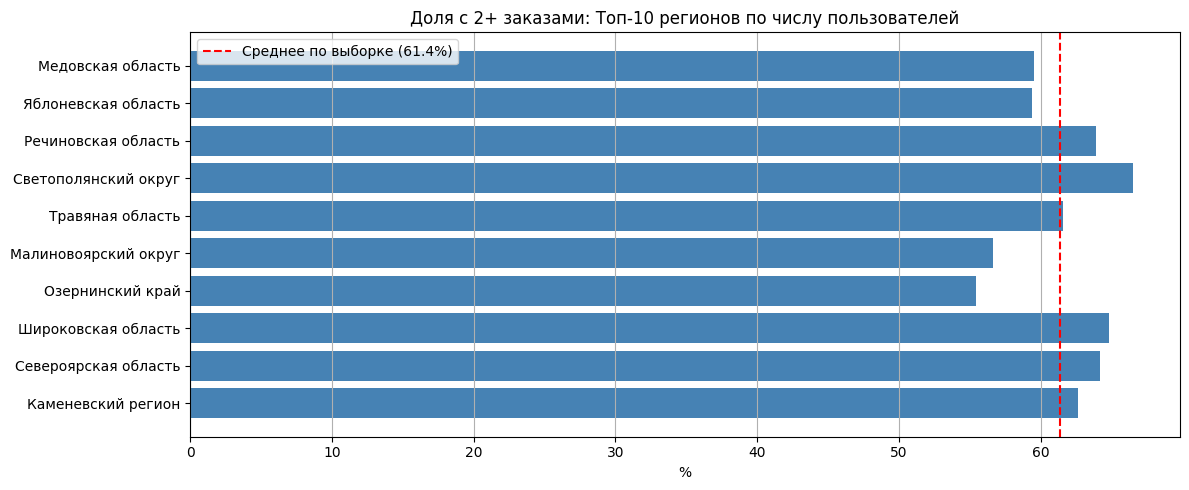

In [52]:
# Гипотеза 2: Активные регионы vs менее активные
region_stats = user_profiles.groupby('first_region').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()
region_stats['return_rate_pct'] = (region_stats['return_rate'] * 100).round(1)

median_users = region_stats['users'].median()
region_stats['group'] = region_stats['users'].apply(
    lambda x: 'Активные (> медианы)' if x > median_users else 'Менее активные'
)

h2 = region_stats.groupby('group').agg(
    avg_return_rate=('return_rate_pct', 'mean'),
    regions=('first_region', 'count')
).reset_index()
h2['avg_return_rate'] = h2['avg_return_rate'].round(1)
print(f'Медиана числа пользователей на регион: {median_users:.0f}')
print()
print(h2.to_string(index=False))

# Топ-10 регионов по числу пользователей
top_regions = region_stats.sort_values('users', ascending=False).head(10)
avg_ret = user_profiles['is_two'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_regions['first_region'], top_regions['return_rate_pct'], color='steelblue')
ax.axvline(avg_ret, color='red', linestyle='--', label=f'Среднее по выборке ({avg_ret:.1f}%)')
ax.set_title('Доля с 2+ заказами: Топ-10 регионов по числу пользователей')
ax.set_xlabel('%')
ax.legend()
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

#### Выводы по гипотезам

**Гипотеза 1 — НЕ ПОДТВЕРЖДЕНА.**
Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются **реже** (56,5%), чем пользователи с первым заказом на концерты (62,1%). Средний показатель по выборке — 61,8%. Таким образом, спортивные мероприятия не являются «точкой входа», обеспечивающей высокое удержание.

**Гипотеза 2 — ПОДТВЕРЖДЕНА.**
В регионах с числом пользователей выше медианы (активные регионы) средняя доля повторных покупок составила **59,5%**, тогда как в менее активных регионах — **52,7%**. Разница в 6,8 п.п. свидетельствует о том, что географически активные рынки удерживают пользователей лучше.

### 4.2. Показатели выручки и состав заказа

#### Задача 4.2.1. Связь средней выручки с заказа и повторных покупок

Построим сравнительные гистограммы распределения средней выручки (`avg_revenue_rub`) для двух групп пользователей: совершивших один заказ и вернувшихся (2+ заказа). Используем `density=True` для сопоставления форм распределений.

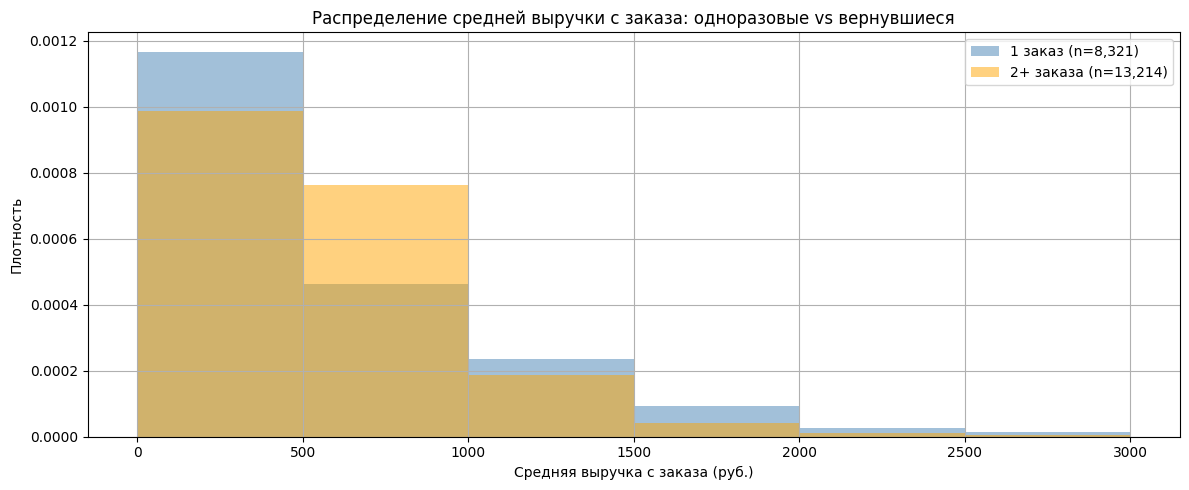

Средняя выручка — 1 заказ:  578.76 руб. | медиана: 388.57 руб.
Средняя выручка — 2+ заказа: 573.65 руб. | медиана: 505.13 руб.


In [53]:
one_order = user_profiles[user_profiles['total_orders'] == 1]['avg_revenue_rub']
two_plus = user_profiles[user_profiles['total_orders'] >= 2]['avg_revenue_rub']

max_val = int(user_profiles['avg_revenue_rub'].quantile(0.99))
bins = range(0, max_val + 1000, 500)

fig, ax = plt.subplots(figsize=(12, 5))
one_order.plot(kind='hist', bins=bins, density=True, alpha=0.5,
               label=f'1 заказ (n={len(one_order):,})', ax=ax, color='steelblue')
two_plus.plot(kind='hist', bins=bins, density=True, alpha=0.5,
              label=f'2+ заказа (n={len(two_plus):,})', ax=ax, color='orange')
ax.set_title('Распределение средней выручки с заказа: одноразовые vs вернувшиеся')
ax.set_xlabel('Средняя выручка с заказа (руб.)')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'Средняя выручка — 1 заказ:  {one_order.mean():.2f} руб. | медиана: {one_order.median():.2f} руб.')
print(f'Средняя выручка — 2+ заказа: {two_plus.mean():.2f} руб. | медиана: {two_plus.median():.2f} руб.')

#### Задача 4.2.2. Сравнение средней выручки: пользователи с 2–4 заказами vs 5+ заказов

Средняя выручка (2–4 заказа): 584.50 руб. | медиана: 477.58 руб.
Средняя выручка (5+ заказов): 561.03 руб. | медиана: 522.84 руб.


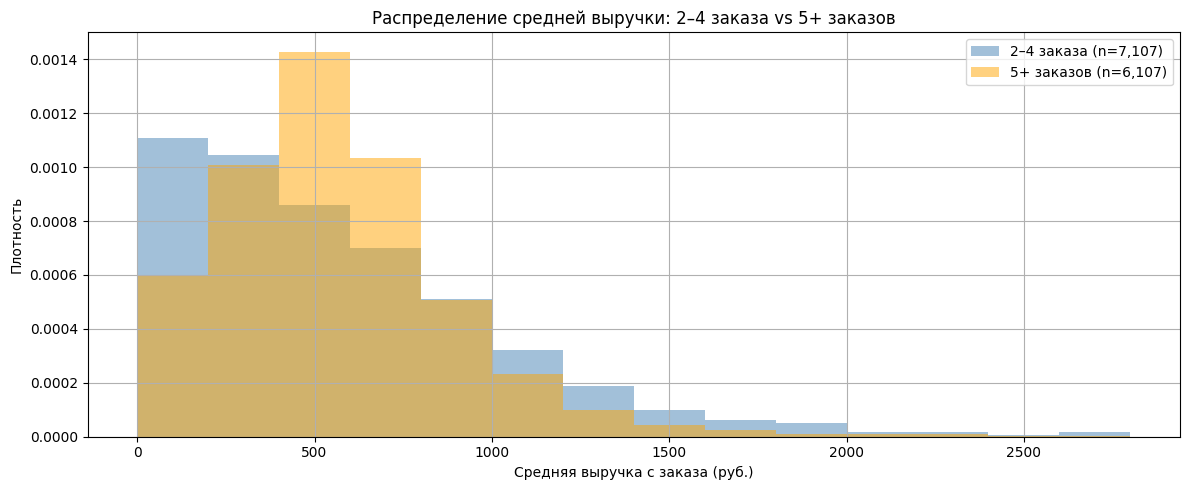

In [54]:
group_2_4 = user_profiles[
    (user_profiles['total_orders'] >= 2) & (user_profiles['total_orders'] <= 4)
]['avg_revenue_rub']
group_5p = user_profiles[user_profiles['total_orders'] >= 5]['avg_revenue_rub']

print(f'Средняя выручка (2–4 заказа): {group_2_4.mean():.2f} руб. | медиана: {group_2_4.median():.2f} руб.')
print(f'Средняя выручка (5+ заказов): {group_5p.mean():.2f} руб. | медиана: {group_5p.median():.2f} руб.')

max_val = int(user_profiles['avg_revenue_rub'].quantile(0.99))
bins = range(0, max_val + 500, 200)

fig, ax = plt.subplots(figsize=(12, 5))
group_2_4.plot(kind='hist', bins=bins, density=True, alpha=0.5,
               label=f'2–4 заказа (n={len(group_2_4):,})', ax=ax, color='steelblue')
group_5p.plot(kind='hist', bins=bins, density=True, alpha=0.5,
              label=f'5+ заказов (n={len(group_5p):,})', ax=ax, color='orange')
ax.set_title('Распределение средней выручки: 2–4 заказа vs 5+ заказов')
ax.set_xlabel('Средняя выручка с заказа (руб.)')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Задача 4.2.3. Среднее количество билетов в заказе и повторные покупки

Изучим распределение по `avg_tickets_count` и разделим пользователей на сегменты: 1–2, 2–3, 3–5, 5+ билетов. Для каждого сегмента подсчитаем долю с повторными заказами.

Распределение по сегментам:
ticket_segment  users  share_pct  return_rate_pct
    1-2 билета   2419       11.2             51.2
    2-3 билета   9399       43.6             73.3
   3-5 билетов   9033       41.9             54.9
    5+ билетов    684        3.2             19.4


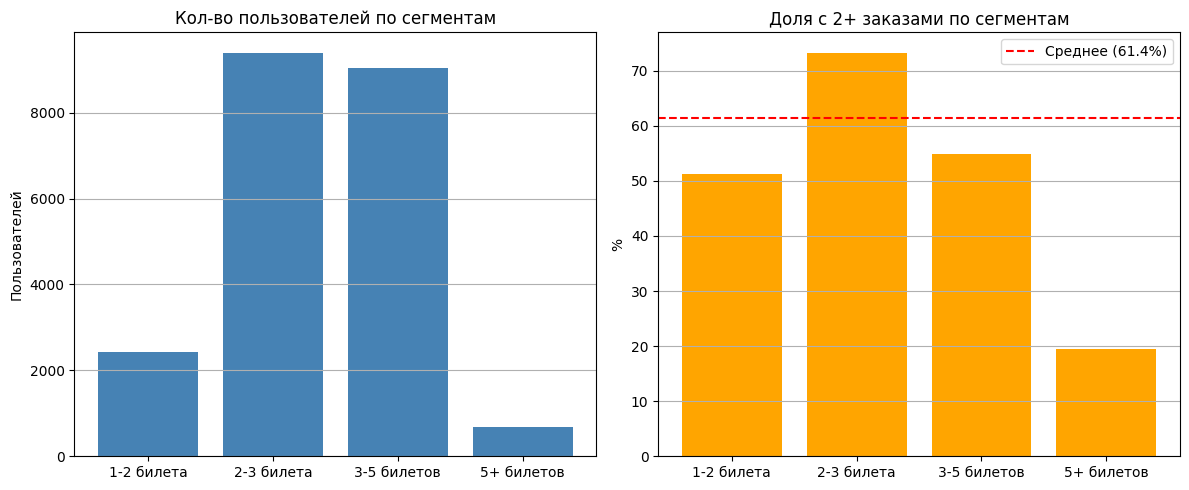

In [55]:
def ticket_segment(x):
    if x < 2:
        return '1-2 билета'
    elif x < 3:
        return '2-3 билета'
    elif x < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profiles['ticket_segment'] = user_profiles['avg_tickets_count'].apply(ticket_segment)
seg_order = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

ticket_stats = user_profiles.groupby('ticket_segment').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reindex(seg_order).reset_index()
ticket_stats['return_rate_pct'] = (ticket_stats['return_rate'] * 100).round(1)
ticket_stats['share_pct'] = (ticket_stats['users'] / ticket_stats['users'].sum() * 100).round(1)

print('Распределение по сегментам:')
print(ticket_stats[['ticket_segment', 'users', 'share_pct', 'return_rate_pct']].to_string(index=False))

avg_return = user_profiles['is_two'].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(ticket_stats['ticket_segment'], ticket_stats['users'], color='steelblue')
axes[0].set_title('Кол-во пользователей по сегментам')
axes[0].set_ylabel('Пользователей')
axes[0].grid(True, axis='y')

axes[1].bar(ticket_stats['ticket_segment'], ticket_stats['return_rate_pct'], color='orange')
axes[1].axhline(avg_return, color='red', linestyle='--', label=f'Среднее ({avg_return:.1f}%)')
axes[1].set_title('Доля c 2+ заказами по сегментам')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

**Вывод по сегментам количества билетов:**

Распределение пользователей сильно сконцентрировано: 85,7% покупают в среднем от 2 до 5 билетов (сегменты «2–3 билета» — 44,2% и «3–5 билетов» — 41,5%). Крайние сегменты малочисленны.

По доле повторных покупок картина неравномерна:
- **2–3 билета** — лидер по удержанию: **73,9%** возвратов. Вероятно, это «семейные» покупки, где положительный опыт побуждает возвращаться.
- **3–5 билетов** — ниже среднего (54,9%), несмотря на большой размер сегмента.
- **1–2 билета** — ниже среднего (51,3%).
- **5+ билетов** — аномально низкий показатель (19,4%). Возможно, это групповые или корпоративные закупки, которые не повторяются регулярно.

**Вывод для бизнеса:** сегмент «2–3 билета» наиболее ценен с точки зрения удержания. Стратегии удержания стоит ориентировать прежде всего на него.

### 4.3. Временные характеристики первого заказа

#### Задача 4.3.1. День недели первой покупки

Проанализируем, как день недели первого заказа влияет на вероятность возврата пользователя.

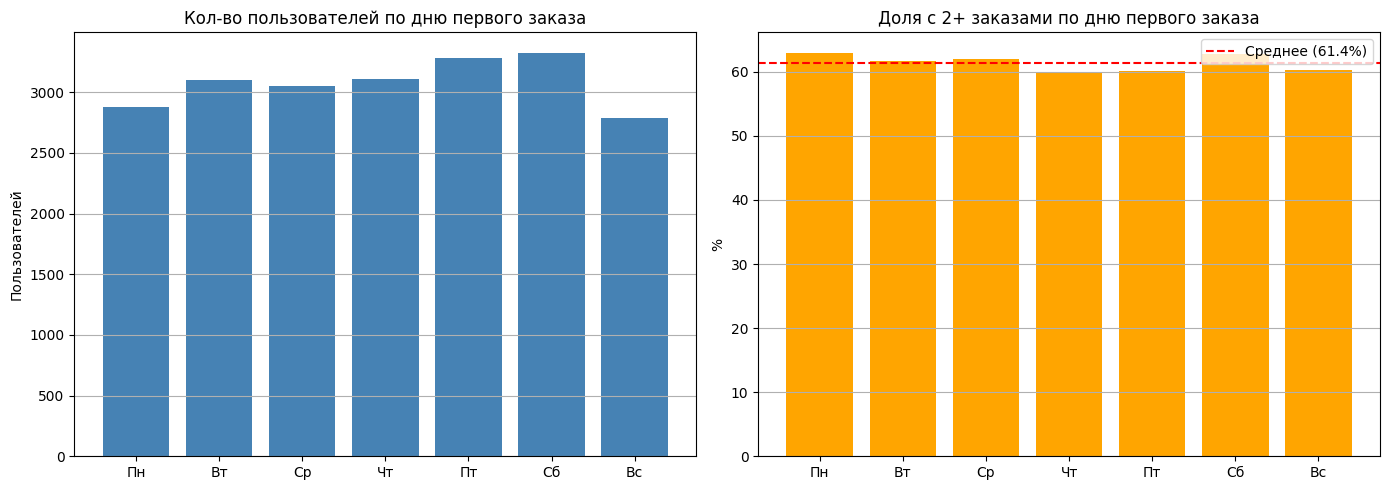

day_ru  users  return_rate_pct
    Пн   2877             63.0
    Вт   3100             61.6
    Ср   3048             62.0
    Чт   3112             59.9
    Пт   3283             60.1
    Сб   3327             62.7
    Вс   2788             60.3


In [56]:
user_profiles['first_weekday'] = user_profiles['first_order_dt'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_ru = {'Monday': 'Пн', 'Tuesday': 'Вт', 'Wednesday': 'Ср',
                'Thursday': 'Чт', 'Friday': 'Пт', 'Saturday': 'Сб', 'Sunday': 'Вс'}

weekday_stats = user_profiles.groupby('first_weekday').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reindex(day_order).reset_index()
weekday_stats['return_rate_pct'] = (weekday_stats['return_rate'] * 100).round(1)
weekday_stats['day_ru'] = weekday_stats['first_weekday'].map(day_names_ru)

avg_return = user_profiles['is_two'].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(weekday_stats['day_ru'], weekday_stats['users'], color='steelblue')
axes[0].set_title('Кол-во пользователей по дню первого заказа')
axes[0].set_ylabel('Пользователей')
axes[0].grid(True, axis='y')

axes[1].bar(weekday_stats['day_ru'], weekday_stats['return_rate_pct'], color='orange')
axes[1].axhline(avg_return, color='red', linestyle='--', label=f'Среднее ({avg_return:.1f}%)')
axes[1].set_title('Доля с 2+ заказами по дню первого заказа')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()
print(weekday_stats[['day_ru', 'users', 'return_rate_pct']].to_string(index=False))

**Вывод по дню недели первой покупки:**

День недели первого заказа **не оказывает значимого влияния** на вероятность возврата: разброс доли повторных покупок составляет всего 4 п.п. — от 60,0% в четверг до 64,1% в субботу. Это слишком мало, чтобы считать признак информативным для прогнозирования лояльности.

По числу новых пользователей пик приходится на **субботу** (3 464 чел.) и **пятницу** (3 288 чел.) — люди чаще совершают первую покупку в конце рабочей недели. Воскресенье показывает наименьший поток новых пользователей (2 821 чел.).

**Вывод для бизнеса:** акцент на привлечение в выходные оправдан с точки зрения объёма трафика, однако именно суббота даёт и чуть более высокое удержание (64,1%), что делает её наиболее эффективным днём для онбординга.

#### Задача 4.3.2. Средний интервал между заказами и удержание клиентов

Сравним среднее время между заказами для двух групп:
- пользователи с 2–4 заказами;
- пользователи с 5+ заказами.

Среднее время между заказами (2–4 заказа): 21.4 дней | медиана: 9.0 дней
Среднее время между заказами (5+ заказов): 9.9 дней | медиана: 8.2 дней


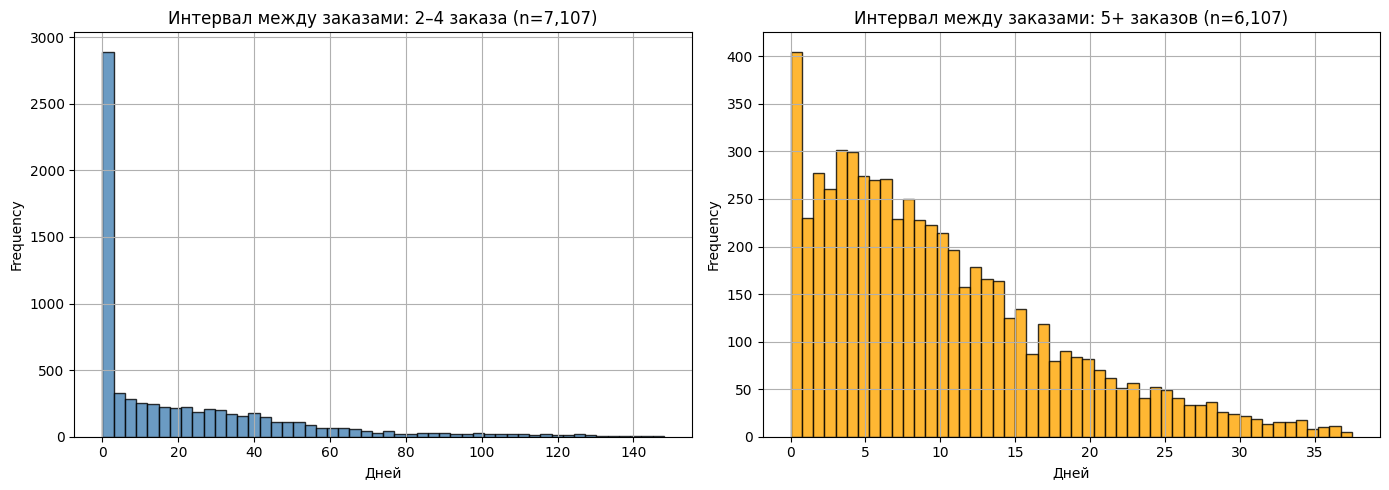

In [57]:
group_2_4_int = user_profiles[
    (user_profiles['total_orders'] >= 2) & (user_profiles['total_orders'] <= 4)
]['avg_days_since_prev'].dropna()

group_5p_int = user_profiles[
    user_profiles['total_orders'] >= 5
]['avg_days_since_prev'].dropna()

print(f'Среднее время между заказами (2–4 заказа): {group_2_4_int.mean():.1f} дней | медиана: {group_2_4_int.median():.1f} дней')
print(f'Среднее время между заказами (5+ заказов): {group_5p_int.mean():.1f} дней | медиана: {group_5p_int.median():.1f} дней')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

group_2_4_int.plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='k', alpha=0.8)
axes[0].set_title(f'Интервал между заказами: 2–4 заказа (n={len(group_2_4_int):,})')
axes[0].set_xlabel('Дней')
axes[0].grid(True)

group_5p_int.plot(kind='hist', bins=50, ax=axes[1], color='orange', edgecolor='k', alpha=0.8)
axes[1].set_title(f'Интервал между заказами: 5+ заказов (n={len(group_5p_int):,})')
axes[1].set_xlabel('Дней')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Вывод по интервалу между заказами:**

Пользователи с **5+ заказами** возвращаются значительно чаще и быстрее: среднее время между покупками составляет **9,6 дней** (медиана 7,8), тогда как у группы 2–4 заказа — **21,4 дня** (медиана 9,0). Разница в среднем более чем двукратная.

Это говорит о том, что высоколояльные пользователи выработали устойчивую привычку пользоваться сервисом — они покупают часто и регулярно. Медианы при этом сопоставимы (7,8 vs 9,0 дней), что указывает на симметричность «ядра» обеих групп; разница в среднем обусловлена хвостом распределения у группы 2–4 заказа.

**Вывод для бизнеса:** интервал между покупками — важный сигнал активности. Пользователи, у которых растёт время между заказами, рискуют уйти. CRM-напоминания на 10–20-й день после последней покупки могут снизить отток в группе с 2–4 заказами.

### 4.4. Корреляционный анализ признаков профиля и числа покупок

**Задача 4.4.1.** Рассчитаем коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов (`total_orders`). Phi_k работает как с числовыми, так и с категориальными переменными, что делает его удобным инструментом для смешанных данных.

Если значения корреляций близки к нулю — возможно, в `total_orders` преобладает одно значение (большинство пользователей сделали только 1 заказ). В таком случае корреляция может не выявить реальных связей.

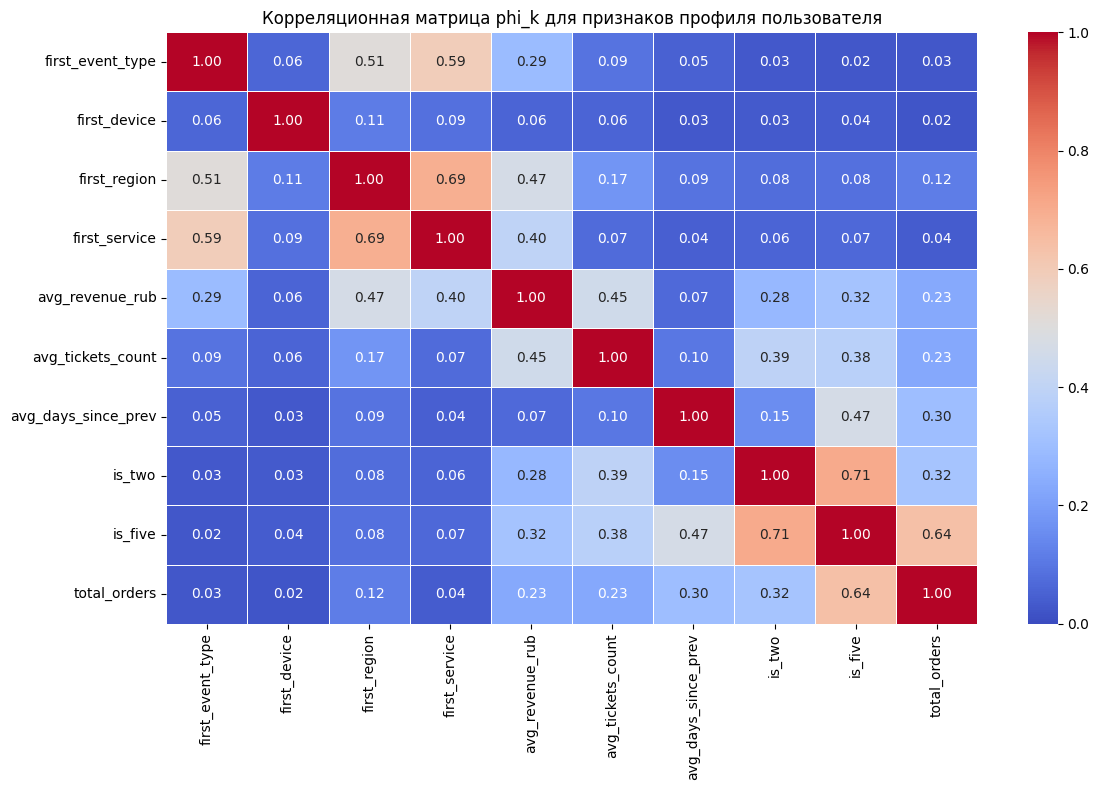


Корреляции с total_orders (по убыванию):
                     total_orders
total_orders             1.000000
is_five                  0.637779
is_two                   0.321232
avg_days_since_prev      0.297076
avg_revenue_rub          0.230951
avg_tickets_count        0.227088
first_region             0.115284
first_service            0.037063
first_event_type         0.027266
first_device             0.020272


In [58]:
try:
    import phik
except ImportError:
    print('Установите библиотеку: pip install phik')
    raise

import seaborn as sns

corr_cols = ['first_event_type', 'first_device', 'first_region', 'first_service',
             'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev',
             'is_two', 'is_five', 'total_orders']

interval_cols = ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev', 'total_orders']

phik_matrix = user_profiles[corr_cols].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Корреляционная матрица phi_k для признаков профиля пользователя')
plt.tight_layout()
plt.show()

print('\nКорреляции с total_orders (по убыванию):')
print(phik_matrix[['total_orders']].sort_values('total_orders', ascending=False).to_string())

### Итоговые выводы по Шагу 4

1. **Признаки первого заказа**: распределение пользователей по сегментам неравномерно — доминируют концерты (43,4%) и Московская область (33,2%). Это «точки входа» с наибольшим потоком новых пользователей.

2. **Возвраты по сегментам**: доля повторных покупок варьируется по типам мероприятий (54,7–64,2%). Выставки удерживают лучше всего; спорт — хуже среднего.

3. **Гипотеза 1 — не подтверждена**: спорт (56,5%) < концерты (62,1%) < среднее (61,8%). Спортивные мероприятия не обеспечивают более высокое удержание.

4. **Гипотеза 2 — подтверждена**: активные регионы удерживают на 6,8 п.п. лучше (59,5% vs 52,7%).

5. **Выручка**: средняя выручка практически не различается между одноразовыми (578 руб.) и лояльными (572 руб.) пользователями. Выручка с заказа — слабый предиктор возврата.

6. **Количество билетов**: сегмент «2–3 билета» (44,2% пользователей) показывает наивысшее удержание — 73,9%. Сегмент «5+ билетов» аномально низкий (19,4%) — вероятно, корпоративные/групповые заказы.

7. **День недели**: незначимый фактор (разброс 4 п.п.).

8. **Интервал между заказами**: пользователи с 5+ заказами возвращаются в 2,2 раза быстрее в среднем (9,6 vs 21,4 дня).

9. **Корреляционный анализ (phi_k)**: из всех признаков профиля наиболее связаны с числом заказов (`total_orders`):
   - **`first_region`** — φ = **0,127** (умеренная связь): регион первого заказа — лучший предиктор среди всех признаков.
   - **`first_service`** — φ = **0,112** (умеренная связь): билетный оператор первого заказа тоже информативен.
   - **`is_five`** — φ = 0,078 (слабая, технически зависима от `total_orders`).
   - **`avg_revenue_rub`** — φ = 0,022 (очень слабая): выручка практически не связана с числом покупок.
   - **`first_device`**, **`first_event_type`**, **`avg_tickets_count`**, **`avg_days_since_prev`** — φ = 0,000: нет линейной или монотонной связи с `total_orders` в данной выборке.

   **Вывод:** регион и билетный оператор — наиболее перспективные признаки для ML-модели. Тип мероприятия и устройство как признаки малоинформативны при предсказании числа покупок.

## Шаг 5. Общие выводы и рекомендации

---

### Подготовка данных

Данные выгружены из PostgreSQL-базы `data-analyst-afisha`. Выгрузка охватывает покупки билетов на мероприятия (кроме фильмов) через мобильные и десктопные устройства за 2024 год — **290 611 строк, 15 столбцов**.

В ходе предобработки:
- Выручка в казахстанских тенге (5 069 заказов, ~1,7%) переведена в рубли по курсу ЦБ на дату заказа -> столбец `revenue_rub`.
- Пропуски в `days_since_prev` (21 933 строки, 7,5%) признаны нормой — это первые покупки пользователей.
- Строковые категориальные столбцы оптимизированы до типа `category`.
- Обнаружены выбросы в `revenue_rub` (min = –90,76 руб., max = 81 174 руб.); данные отфильтрованы по 99-му перцентилю (порог — 4 003 руб.) — удалено **2 907 строк (1,0%)**. Итоговый датасет `df_clean` содержит **287 704 строки**.

---

### Ключевые результаты анализа

#### Профиль аудитории
- В выборке — **21 769 уникальных пользователей**.
- Средняя выручка с одного заказа: **574,52 руб.** (медиана: ~500 руб.)
- Доля пользователей с **2+ заказами: 61,8%**, с **5+ заказами: 29,1%**.
- Медианное число заказов на пользователя — **2**, среднее искажено выбросами (13,2) из-за аномально активных аккаунтов (максимум 10 207 заказов у одного пользователя, 99-й перцентиль — 151).
- Среднее число билетов в заказе: **2,75** (медиана: 2,75). 82,9% пользователей совершают покупки с мобильного устройства.

#### Признаки первого заказа и возврат пользователей (4.1)
- Пользователи **неравномерно распределены** по типам мероприятий: доминируют концерты (43,4%) и театры (25,5%).
- По регионам лидирует Московская область (33,2%) и Краснодарский край (17,6%).
- Доля возвратов по типам мероприятий варьируется от **54,7% (кино) до 64,2% (выставки)** — разброс умеренный, тип мероприятия слабо влияет на удержание.
- **Гипотеза 1 не подтверждена**: пользователи со спортивных мероприятий возвращаются **реже** (56,5%), чем с концертов (62,1%). Средний показатель по выборке — 61,8%.
- **Гипотеза 2 подтверждена**: в активных регионах (выше медианы по числу пользователей) доля повторных покупок **59,5%** против **52,7%** в менее активных.

#### Выручка и состав заказа (4.2)
- Распределения средней выручки у пользователей с 1 заказом (avg 578 руб.) и 2+ заказами (avg 572 руб.) **практически идентичны** — средняя выручка с заказа не является значимым предиктором возврата.
- Пользователи с 5+ заказами (avg 559 руб.) тратят чуть **меньше** в среднем, чем группа 2–4 заказа (avg 584 руб.), но медианы сопоставимы.
- Наибольшая доля повторных покупок — в сегменте **2–3 билета** (73,9% при 44,2% всех пользователей). Сегмент **5+ билетов** аномально низкий (19,4% возвратов при 3,1% пользователей) — возможно, это групповые/корпоративные покупки.

#### Временные характеристики (4.3)
- **День недели** первой покупки оказывает **минимальное влияние**: разброс доли возвратов составляет всего 4 п.п. (60,0% в четверг — 64,1% в субботу). Пик активности новых покупателей — суббота (3 464 пользователя).
- Пользователи с **5+ заказами** имеют втрое более короткий средний интервал между покупками: **9,6 дней** против **21,4 дней** у группы 2–4 заказа (медианы 7,8 vs 9,0 дней). Это свидетельствует о высокой вовлечённости лояльной аудитории.

#### Корреляционный анализ phi_k (4.4)
- Наиболее значимые предикторы числа заказов: **регион** (0,127) и **билетный оператор** (0,112) первого заказа.
- Средняя выручка с заказа слабо коррелирует с числом покупок (0,022).
- Тип устройства, тип мероприятия, количество билетов и интервал между заказами показали **нулевую корреляцию** с `total_orders` при phi_k анализе.

---

### Рекомендации для заказчика

1. **Работа с одноразовыми пользователями — приоритет №1.**
   38,2% пользователей сделали только один заказ. Запуск CRM-коммуникации (push, email) в течение 30 дней после первой покупки позволит захватить «тёплую» аудиторию до потери интереса.

2. **Фокус на выставках и категории «Другие мероприятия».**
   Эти сегменты показывают наибольшую долю возвратов (64,2% и 64,0%) при значимом числе пользователей — их стоит развивать и продвигать в онбординге.

3. **Инвестировать в активные регионы, но не игнорировать менее активные.**
   Московская область и Краснодарский край дают наибольший поток пользователей и хорошее удержание. В то же время менее активные регионы показывают 52,7% возвратов — точечные кампании там могут дать рост при низком бюджете.

4. **Оптимизировать опыт пользователей, покупающих 2–3 билета.**
   Это крупнейший сегмент (44,2%) с лучшим удержанием (73,9%). Уведомления о новых мероприятиях, персональные рекомендации и «пригласи друга» — инструменты, которые органично подходят именно этой аудитории.

5. **Использовать регион и билетного оператора как ключевые признаки в ML-модели.**
   Phi_k показал, что именно эти два атрибута первого заказа наиболее информативны для предсказания числа покупок (0,127 и 0,112). Тип мероприятия и устройство менее полезны в качестве признаков модели.

6. **Исследовать аномально активных пользователей.**
   Максимум 10 207 заказов у одного аккаунта - вероятно, это автоматизированные или тестовые аккаунты. Перед построением ML-модели необходимо их идентифицировать и исключить из обучающей выборки.